<div style="display:block" direction=rtl align=right><br><br>
    <div  style="width:100%;margin:100;display:block"  display=block align=center>
        <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
        <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
        <span><br><font size=5>University of Tehran , school of ECE</font></span>
        <span><br><font size=3>Cognitive Neuroscience Course</font></span>
        <span><br><font size=3>Summer 1404</font></span>
    </div><br><br><br>
    <div style="display:block" align=left display=block>
        <font size=3>Hands-on fMRI</font><br>
        <hr />
        <font size=3>Is there any <font color=red>؟</font> Question <font color=red>?</font> , Feel free to ask me  <a href="mailto:mohammad.nili@ut.ac.ir">mohammad nili</a> :)))<br></font><br>
    </div>
</div>

In [ ]:
!pip install nilearn nibabel

<pre>
Read / manipulation Data & statistics
$ ( click to jump on task )
.
├── Data Manipulation
│   ├── Task-fMRI data headers
│   └── Load Data <a href="#t1">task 1 - Visualize middle axis of T1w image.</a>
│   
├── General Linear Model (GLM)
│   ├── Event Matrix: <a href="#t2">task 2 -  EV generation.</a>
│   ├── Designt matrix: <a href="#t3">task 3 - Change hrf and drift models.</a>
│   ├── Model Fitting: <a href="#t4">task 4 - Fit GLM model.</a>
│   └── Compare Contrast: <a href="#t5">task 5 - LVF and RVF contrast of LGN.</a>
|       
└── Visualization the results
    └── z-score: <a href="#t6">task 6 - overlay and visualize the results.</a>


</pre>

<font color=green>Use :</font> ``` ! conda install pandas numpy matplotlib ... ```

or

<font color=red> use :</font> ``` ! pip install pandas numpy matplotlib ...```

In [ ]:
from nilearn.glm.first_level import make_first_level_design_matrix
path='/mnili/data'
import matplotlib.pyplot as plt
import nibabel as nib
import nilearn as ni
import pandas as pd
import numpy as np
from nilearn.glm.first_level import FirstLevelModel

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# این دستور فایل زیپ شما را می‌خواند و در پوشه‌ای در خود کلَب از حالت فشرده خارج می‌کند
!unzip "/content/drive/MyDrive/fMRI_Data.zip" -d "/content/fMRI_Data/"

Archive:  /content/drive/MyDrive/fMRI_Data.zip
replace /content/fMRI_Data/preprocessed/ROIs/lh_LGN.nii.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

![image.png](attachment:image.png)

# Data Manipulation
## Task-fMRI data headers
#### localizer:
	"EchoTime": 0.04,
	"RepetitionTime": 2.5,
      Dimensions:        122 x 122 x 22 x 120  
      Voxel size:        1.83607 x 1.83607 x 1.89 x 2.5
    
    local_start: 8 sec
    
#### Main Task:
	"EchoTime": 0.04,
	"RepetitionTime": 2.5,
       Dimensions:        122 x 122 x 21 x 250
       Voxel size:        1.83607 x 1.83607 x 1.89 x 2.5

    main_start magno: 32 sec

<div dir="rtl">
عداد 122 x 122 x 22 x 120 یعنی چه؟این یک ماتریس ۴ بعدی (4D) است که نشان می‌دهد دستگاه، مغز را به چند تا «جعبه کوچک» تقسیم کرده است:122 (X): تعداد واکسل‌ها در محور چپ به راست.122 (Y): تعداد واکسل‌ها در محور جلو به عقب.22 (Z): تعداد برش‌ها یا لایه‌های مغز (از پایین به بالا).120 (T): تعداد کل زمان‌ها (Volumeها) که دستگاه از کل مغز عکس گرفته است. (یعنی این اسکن شامل 120 عکس سه‌بعدیِ پشت سر هم است).(نکته: ماتریس ایونت یا $X$ در GLM، ماتریسی است که خودت بعداً با پایتون می‌سازی که سطرهايش برابر با 120 و ستون‌هایش برابر با تعداد متغیرهای آزمایشت است).۲. بخش Voxel size (اندازه واکسل)تصور اشتباه: مگه نقاط ایکس و ایگرگ مغز نیستند؟ پس چرا اعشاری‌اند؟پاسخ: Dimensions به ما گفت "چند تا" جعبه (واکسل) داریم. اما Voxel size به ما می‌گوید اندازه فیزیکیِ واقعیِ هر کدام از این جعبه‌ها در دنیای واقعی چقدر است!به اعداد 1.83607 x 1.83607 x 1.89 x 2.5 نگاه کن. این اعداد اعشاری هستند چون میلی‌متر (mm) و ثانیه (sec) را نشان می‌دهند:X و Y و Z (1.83607 و 1.83607 و 1.89): این یعنی هر یک دانه از آن جعبه‌های کوچکی که مغز را تشکیل داده‌اند، طول و عرضش حدود 1.8 میلی‌متر و ارتفاعش 1.89 میلی‌متر است. این در واقع رزولوشن تصویر توست
</div>

ub-05_desc-preproc_T1w.nii.gz:
این یک تصویر ساختاری هستش که پیش پردازش  شده است.
sub-05_desc-brain.nii.gz:
قسمت های اضافی مغز مثل ناحیه اب نخاعی و اینها برداشته شده اس.

## load Data

In [ ]:
import nibabel as nib


# thsi is anatomic picture which is has high quality
t1 = nib.load("/content/fMRI_Data/preprocessed/sub-05_desc-brain.nii.gz")

 # this is functional one
#this is just for one patient
fmri1_loc = nib.load("/content/fMRI_Data/preprocessed/sub-05_task-rest_run-1_space-T1w_desc-preproc_bold.nii.gz")

<div dir="rtl">
اینجا رو باید تغییر بدم
خود داده لابد ار دستور
get_fdata
ما تو این بخش فقط اون داده ساختاری رو اپلود کردیو تصویر fmri یک نفر که تمیز شده هست.
</div>

In [ ]:
# Get data shapes
t1_data = t1.get_fdata()
#اینجا اومده اون ماتریس ساختاری رو رفته پیکسل به پیکسل گرفته  و تبدیلش میکنه به یک نامپای
#فرقش با لود همینه و الان جنس ما از جنس نامپای شده است
bold_data = fmri1_loc.get_fdata()
#الان هم نامپای داریم
print('T1w shape:', t1_data.shape)
print('BOLD shape:', bold_data.shape)

T1w shape: (176, 256, 256)
BOLD shape: (78, 92, 74, 120)


<div dir="rtl">

یکی عکس شکل ساختاری هست و ابعاد واکسل ها را نشان میدهد و دیگری سیگنال بولد است که ابعاد کل سیگنال های بولد مفز را نشان میدهد که به وضوح کیفیت کمتری دارد
</div>

<hr />
<font color=red size=5 id="t1"> 🧠 Challenge 1 :</font>

Plot the middle slice of the T1-weighted image.
Use `matplotlib.pyplot.imshow` and display the middle axial slice.

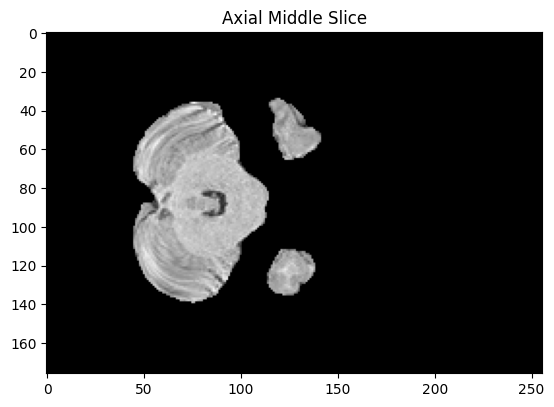

In [ ]:
import matplotlib.pyplot as plt

# پیدا کردن شماره لایه وسط در محور Z (نمای اگزیال)
middle_z = t1_data.shape[2] // 2  # 256 // 2 = 128

# بریدن ماتریس برای به دست آوردن یک عکس دو بعدی
middle_slice_axial = t1_data[:, :, middle_z]

# نمایش عکس
plt.imshow(middle_slice_axial, cmap='gray')
plt.title("Axial Middle Slice")
plt.show()

اینجا ماتریس ایونت رو میسازم
که داره میگه در هر 2.5 ثانیه چه اتفاقی افتاده من میدونم تسک من از ثانیه 8 ام شروع شده یعنی 8 ثانیه اول هیچ محرکی شروع نشده
و از ثانیه 8.25 شروع کردیم به نمایش محرک ها
13 ثانیه محرک سمت چپ
و هر 13 ثانیه چپ راست جپ راست
پس هی چپ راست چپ راست نمایش داده شده است.

# General Linear Model
### Event Matrix generation

توجه کن اینجا در واقع اطلاعات 0 و1 و اینها رو وارد میکنی بعد خود این کار باعث میشه که بگی سمت چپ هست سمت راست هست و با توجه به هر ثانیه هست که مشخص کرده

<hr />
<font color=red size=5 id="t2"> 🧠 Challenge 2 :</font>

Complete below code to make Event matrix...

In [ ]:
import numpy as np
import pandas as pd

# Parameters
TR = 2.5  # Repetition time in seconds
num_volumes = 120  # Total number of volumes
block_duration = 13  # Block duration in seconds
task_start_time = 8.25  # Task starts after 8 seconds
total_time = num_volumes * TR  # Total fMRI scan time

# Time points corresponding to each volume
onset_times = np.arange(0, total_time, TR)
#داره یک ارایه چند بعدی میسازه که 2.5 ثانیه 2.5 ثانیه زیاد میشه

# Initialize the design matrix with zeros and add a duration column
#nilearn ازمون میخواد دقیقا یک دیتا فریم دقیقا با همین سه ستون با همین نام ها بسازیم
#اینجا از دیکشنری تبدیلش کرده به دیتا فریم
events_matrix = pd.DataFrame({'onset': onset_times,
                              'trial_type': np.zeros(len(onset_times)),
                              'duration': np.ones(len(onset_times)) * TR})

# Loop through time points and alternate task blocks between 1 and 2
current_time = task_start_time
task_state = 1  # Start with Task_Block 1

while current_time < total_time:
    # FILL 1: The block ends after 'block_duration' seconds
    block_end_time = current_time + block_duration
    if block_end_time > total_time:
        block_end_time = total_time
  #اینجا در واقع اومدیم فرض نوشتیم
    events_matrix.loc[(events_matrix['onset'] >= current_time) & (events_matrix['onset'] < block_end_time), 'trial_type'] = task_state

    # FILL 2: Alternate task state between 1 and 2
    task_state = 2 if task_state == 1 else 1

    # Move to the next block
    current_time = block_end_time

events_matrix.loc[120-7:,'trial_type'] = 0
events_matrix['trial_type'] = events_matrix['trial_type'].astype(str)

print(events_matrix.head(10))
print(events_matrix.tail(10))

   onset trial_type  duration
0    0.0        0.0       2.5
1    2.5        0.0       2.5
2    5.0        0.0       2.5
3    7.5        0.0       2.5
4   10.0        1.0       2.5
5   12.5        1.0       2.5
6   15.0        1.0       2.5
7   17.5        1.0       2.5
8   20.0        1.0       2.5
9   22.5        2.0       2.5
     onset trial_type  duration
110  275.0        1.0       2.5
111  277.5        1.0       2.5
112  280.0        1.0       2.5
113  282.5        0.0       2.5
114  285.0        0.0       2.5
115  287.5        0.0       2.5
116  290.0        0.0       2.5
117  292.5        0.0       2.5
118  295.0        0.0       2.5
119  297.5        0.0       2.5


\<div dir="rtl">
خب اینجا ما هر 13 ثانیه داریم یک عکس روی مانتیور نشون میدیم  و هر 2.5 ثانیه عکس میگیرم یعنی به حدود 5 تا عکس باید تایپشون یکی باشه. اخری ها هم 0 هست .

</div>

In [ ]:
events_matrix.head(20)

,onset,trial_type,duration
0,0.0,0.0,2.5
1,2.5,0.0,2.5
2,5.0,0.0,2.5
3,7.5,0.0,2.5
4,10.0,1.0,2.5
5,12.5,1.0,2.5
6,15.0,1.0,2.5
7,17.5,1.0,2.5
8,20.0,1.0,2.5
9,22.5,2.0,2.5


## Design matrix

<font color=red size=5 id="t3"> 🧠 Challenge 3 :</font>

Change the `dritf_model` and `hrf_model` in your GLM and compare the results:

In [ ]:
help(make_first_level_design_matrix)

Help on function make_first_level_design_matrix in module nilearn.glm.first_level.design_matrix:

make_first_level_design_matrix(frame_times, events=None, hrf_model='glover', drift_model='cosine', high_pass=0.01, drift_order=1, fir_delays=None, add_regs=None, add_reg_names=None, min_onset=-24, oversampling=50)
    Generate a design matrix from the input parameters.

    Parameters
    ----------
    frame_times : array of shape (n_frames,)
        The timing of acquisition of the scans in seconds.

    events : :obj:`pandas.DataFrame` instance,              or :obj:`str` or :obj:`pathlib.Path` to a CSV or TSV file,              or None, default=None
        Events data that describes the experimental paradigm.
        The resulting DataFrame instance must/may have these keys:

        - ``'onset'``: REQUIRED
            Column to specify the start time of each events in seconds.
            An error is raised if this key is missing.

        - ``'duration'``: REQUIRED
            Colum

In [ ]:
from nilearn.glm.first_level import make_first_level_design_matrix
import numpy as np

# ۱. ساخت بردار زمانِ گرفته شدن عکس‌ها
# دستگاه ۱۲۰ عکس گرفته که هر کدام ۲.۵ ثانیه طول کشیده است
frame_times = np.arange(num_volumes) * TR  # خروجی: [0.0, 2.5, 5.0, ..., 297.5]

# ۲. ساخت ماتریس طراحی
design_matrix = make_first_level_design_matrix(
    frame_times=frame_times,#یعنی 2.5 ثانیه 2.5 ثانیه عکس گرفته و شده 120 تا عکس
    events=events_matrix,# باید رخداد هامون رو وارد کنید که عین یکسری اسپایک مییمونه
#با کمک تابع اچ ای اف میاد از حالت خشک 0و1 درمیاره
    hrf_model='glover',
    #دریفت ها هم کسینوس های  ریزی هستند که انقدر کم کم از اون سیگنال
    #بولد کم میشن که 0 میشن
    drift_model='cosine',
    high_pass=0.01
)
#در واقع اینجا باید حرکت های سر هم به عنوان ستون های ماتریس در نظر میگرفتیم
#و در نظر نگرفتیم و در قسمت های بعد در نظر میگیریم

# نمایش چند ردیف اول ماتریس نهایی
print(design_matrix.head())

           0.0  1.0  2.0   drift_1   drift_2   drift_3   drift_4   drift_5  \
0.0   0.000000  0.0  0.0  0.129088  0.129055  0.129000  0.128923  0.128823   
2.5   0.061408  0.0  0.0  0.129000  0.128701  0.128205  0.127510  0.126619   
5.0   0.706961  0.0  0.0  0.128823  0.127995  0.126619  0.124700  0.122248   
7.5   1.408667  0.0  0.0  0.128558  0.126938  0.124252  0.120525  0.115786   
10.0  1.542688  0.0  0.0  0.128205  0.125532  0.121120  0.115028  0.107342   

       drift_6  constant  
0.0   0.128701       1.0  
2.5   0.125532       1.0  
5.0   0.119272       1.0  
7.5   0.110075       1.0  
10.0  0.098168       1.0  


In [ ]:
tr = 2.5  # repetition time is 2.5 second

dsgn_mx1 =make_first_level_design_matrix(np.arange(fmri1_loc.shape[-1]) * tr,drift_model='cosine',
                                        events=events_matrix,hrf_model="glover + derivative + dispersion")

<div dir="rtl">

**۱. مدل پایه SPM**

نرم‌افزار SPM (Statistical Parametric Mapping) از شناخته‌شده‌ترین و قدیمی‌ترین ابزارها در حوزه تحلیل داده‌های fMRI به‌شمار می‌رود. مدل پایه این نرم‌افزار که با نام «spm» شناخته می‌شود، از یک تابع ریاضی ویژه — ترکیبی از دو تابع گاما — برای مدل‌سازی شکل منحنی خون‌رسانی مغزی استفاده می‌کند.

در مقایسه با مدل Glover، مستندات کتابخانه Nilearn در پایتون نشان می‌دهد که در اغلب موارد، تفاوت معناداری میان خروجی‌های این دو مدل وجود ندارد و انتخاب هر یک از آن‌ها تأثیر چندانی بر نتایج کلی تحلیل نمی‌گذارد. با این حال، در محیط‌های برنامه‌نویسی مانند Nilearn، مدل Glover معمولاً به‌عنوان گزینه پیش‌فرض در نظر گرفته می‌شود.

**۲. مدل دارای مشتق زمانی (spm + derivative یا glover + derivative)**

در این حالت، به‌جای ساخت یک ستون برای هر رویداد (Task)، دو ستون در ماتریس طراحی (X) ایجاد می‌شود: ستون اول نمایانگر موج اصلی خون‌رسانی و ستون دوم مشتق زمانی (Time Derivative) آن است.

کاربرد اصلی این روش در شرایطی است که پاسخ همودینامیک مغز با تأخیر زمانی همراه باشد. برای نمونه، اگر پاسخ خون‌رسانی مغز یک بیمار نسبت به الگوی ایده‌آل ریاضی، حدود یک ثانیه دیرتر رخ دهد، مدل ساده Glover تطابق کافی با داده واقعی نخواهد داشت. افزودن مشتق زمانی به الگوریتم مدل خطی عمومی (GLM) این امکان را می‌دهد که موج پاسخ در محور زمان اندکی جابه‌جا شود تا با سیگنال واقعی ثبت‌شده از هر واکسل هماهنگ‌تر گردد.

**۳. مدل دارای مشتق پراکندگی (spm + derivative + dispersion یا glover + derivative + dispersion)**

این مدل، علاوه بر موج اصلی و مشتق زمانی، یک ستون سوم با عنوان مشتق پراکندگی (Dispersion Derivative) به ماتریس طراحی اضافه می‌کند. برخلاف مشتق زمانی که به جابه‌جایی زمانی موج می‌پردازد، مشتق پراکندگی برای شرایطی به‌کار می‌رود که پاسخ همودینامیک نه از نظر زمانِ وقوع، بلکه از نظر طول مدت یا پهنای منحنی با مدل استاندارد تفاوت دارد.

در برخی موارد، سیگنال خون‌رسانی مغز ممکن است طولانی‌تر یا کوتاه‌تر از حالت ایده‌آل باشد؛ به عبارت دیگر، پهنای قله مشاهده‌شده در نمودار می‌تواند بیشتر یا کمتر از مقدار پیش‌بینی‌شده توسط فرمول پایه باشد. مشتق پراکندگی به مدل GLM اجازه می‌دهد که عرض این موج را به‌صورت انعطاف‌پذیر تنظیم کند تا انطباق بهتری با ویژگی‌های فیزیولوژیک هر واکسل حاصل شود.

**۴. مدل پاسخ ضربه محدود (FIR)**

مدل FIR که مخفف Finite Impulse Response است، رویکردی اساساً متفاوت با مدل‌های پیشین اتخاذ می‌کند. در حالی که مدل‌هایی مانند Glover و SPM بر این فرض استوارند که شکل پاسخ همودینامیک از پیش مشخص است (موجی با یک قله اصلی و یک فرورفتگی جزئی در انتها)، مدل FIR هیچ پیش‌فرضی درباره شکل این پاسخ در نظر نمی‌گیرد.

در این روش، سیگنال پاسخ در بازه‌های زمانی معین (مانند صفر، دو، چهار ثانیه و غیره) به‌صورت مجموعه‌ای از نقاط گسسته (توابع ضربه) تخمین زده می‌شود و شکل منحنی مستقیماً از داده‌ها استخراج می‌گردد. این مدل انعطاف‌پذیری بسیار بالایی دارد، اما در عین حال پیچیدگی محاسباتی آن افزایش یافته و به داده‌های طولانی‌تری برای برآورد پایدار نیازمند است.

**۵. مدل شخصی‌سازی‌شده (Custom Model)**

علاوه بر مدل‌های از پیش تعریف‌شده، امکان تعریف توابع ریاضی سفارشی در محیط‌های برنامه‌نویسی مانند پایتون وجود دارد. پژوهشگر می‌تواند بر پایه یافته‌های جدید یا نیازهای خاص یک جمعیت بالینی، تابع پاسخ همودینامیک اختصاصی خود را طراحی و به‌عنوان ورودی مدل معرفی کند. این قابلیت، انعطاف‌پذیری تحلیل را برای مطالعات تخصصی و شرایط غیراستاندارد به میزان قابل توجهی افزایش می‌دهد.

</div>

\<div dir="rtl">

</div>

,0.0,0.0_derivative,0.0_dispersion,1.0,1.0_derivative,1.0_dispersion,2.0,2.0_derivative,2.0_dispersion,drift_1,drift_2,drift_3,drift_4,drift_5,drift_6,constant
0.0,0.000000,0.000000,-2.874967e-18,0.0,0.0,-1.288788e-17,0.0,0.0,-2.453736e-17,0.129088,0.129055,0.129000,0.128923,0.128823,0.128701,1.0
2.5,0.061408,0.101480,-1.136282e-01,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.129000,0.128701,0.128205,0.127510,0.126619,0.125532,1.0
5.0,0.706961,0.334237,-1.168289e-01,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.128823,0.127995,0.126619,0.124700,0.122248,0.119272,1.0
7.5,1.408667,0.149464,1.166255e-01,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.128558,0.126938,0.124252,0.120525,0.115786,0.110075,1.0
10.0,1.542688,-0.063549,3.632074e-03,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.128205,0.125532,0.121120,0.115028,0.107342,0.098168,1.0


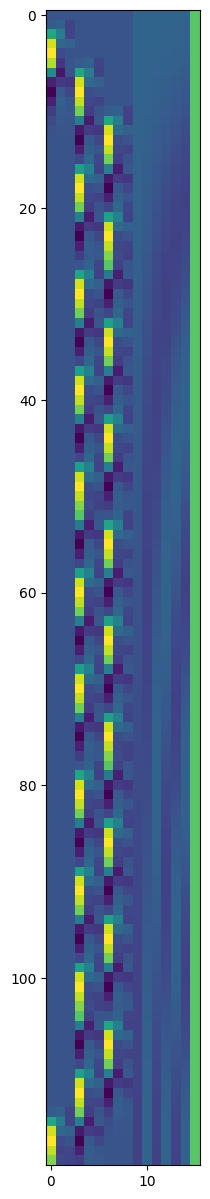

In [ ]:
display(dsgn_mx1.head())
plt.figure(figsize=(20,15))
plt.imshow(dsgn_mx1)


<div dir="rtl">
ببیند ما یک سیگنال بولد داریم که همون ایگرگ هست سیگنال بولد ما برای یک نقطه از مغز هست فقط و سطر هاش 120 تاست. یک ماتریس ایکس هم داریم که در واقع انگار محیط ازمایش ماست.
نکته ای که هست اینه که ما میخواهیم ببینیم در اطراف کدوم نواحی از مغز خون رسانی بیشتر شده. وقتی که نقطه از مغز بیشتر کار میکنه واضحا خون رسانی تو اون نقطه بیشتر میشه
ما میخواهیم نواحی رو پیدا کنیم که همون زمانی که ما رخدادمون اتفاق افتاد مثلا عکس ها نمایش داده شد ما ببینیم که اره تو این نقاط هم خون رسانی بیشتر شده.
خب حالا ما تو ماتریس ایکسمون محیطمون رو شبیه سازی کردیم انگار . محیط ما چی داره؟ یکی از ستون های مهمی که داره همین نمایش رخداد عکس هست مثلا عکس که رخ میده ما انتظار داریم خون رسانی
بیشتر بشه . یک ستون دیگه احتمالا گرم شدن دستگاه باید باشه . یک ستون دیگه میتونه نویز های دیگه باشه که با کمک الگوریتم هایی ما ما اینها رو به
دست میاریم و بهشون میگیم نویز
حالا توجه کنید ما اصلا هنوز به ایگرگ دست نزدیم یعنی به همون سیگنال واقعی نقاط مغزمون اما فکر میکنم این یک حالت ایده ال هست داره میگه در بهتری حالت چی میشه
</div>

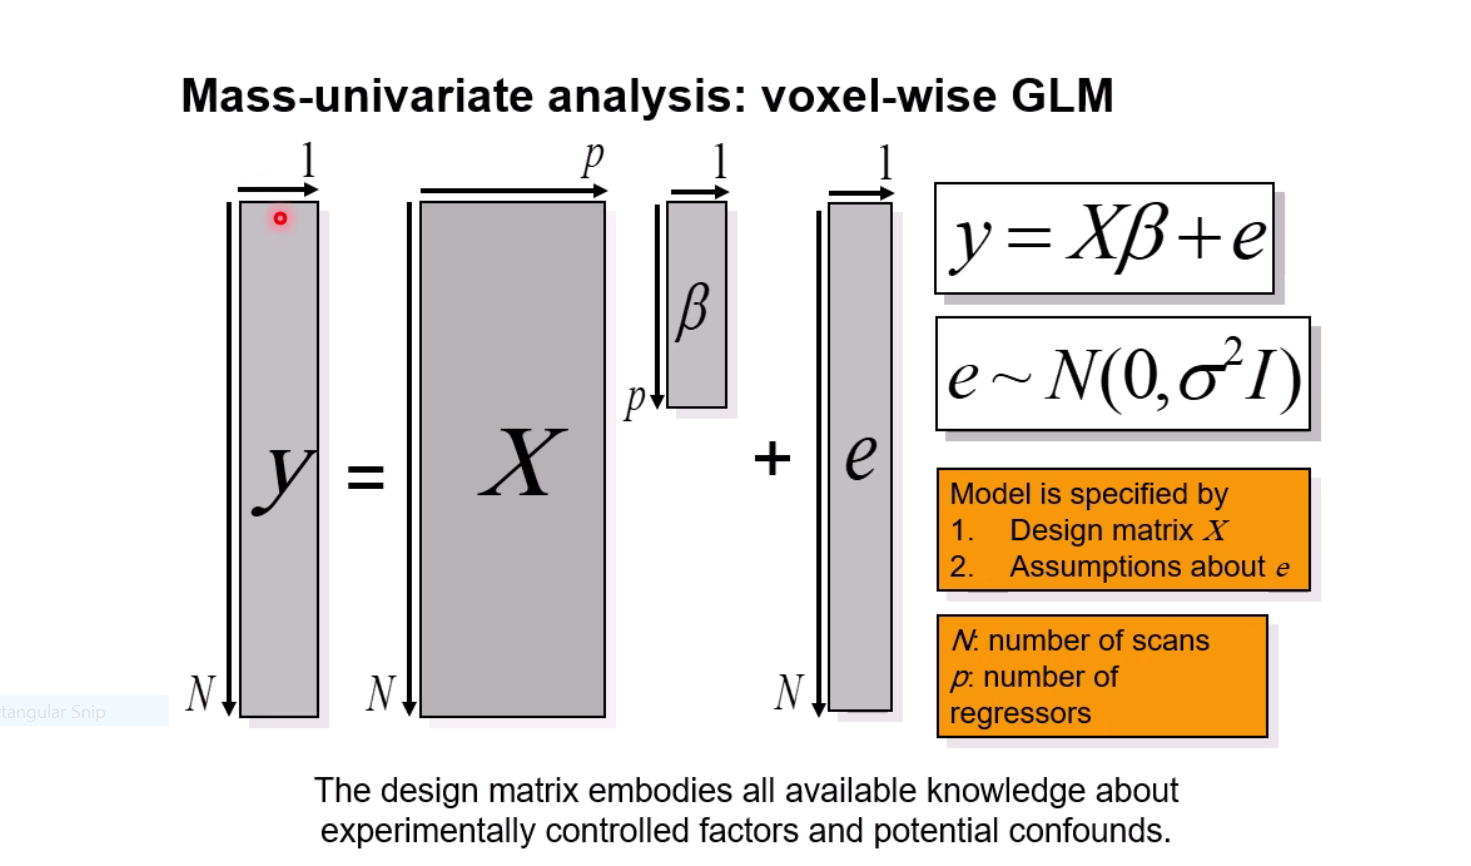

## Drop confounders + fit GLM

In [ ]:
confound_vars = [
    'csf', 'white_matter', 'global_signal',
    'framewise_displacement',
    't_comp_cor_00', 't_comp_cor_01', 't_comp_cor_02',
    'trans_x', 'trans_y', 'trans_z',
    'rot_x', 'rot_y', 'rot_z'
]

Let \( Y(t) \) be the observed fMRI signal at time \( t \), the GLM can be written as:

$$
Y(t) = \sum_{i=1}^{k} \beta_i \cdot X_i(t) + \varepsilon(t)
$$

Where:  
$ X_i(t) $: columns of the design matrix (task-related regressors convolved with HRF, temporal and dispersion derivatives, drift terms) </br>
$ \beta_i $: regression coefficients to be estimated </br>
$ \varepsilon(t) $: residual error at time \( t \) </br>

More specifically:

$$
Y(t) = \beta_1 \cdot h(t) + \beta_2 \cdot h'(t) + \beta_3 \cdot h''(t) + \sum_{j=1}^{J} \gamma_j \cdot D_j(t) + \varepsilon(t)
$$

Where:  
$ h(t) $: the canonical Glover hemodynamic response function (HRF) </br>
$ h'(t) $: the temporal derivative of the HRF </br>
$ h''(t) $: the dispersion derivative of the HRF </br>
$ D_j(t) $: the \( j \)-th cosine drift term </br>
$ \beta_1, \beta_2, \beta_3 $: the regression coefficients for the HRF and its derivatives </br>
$ \gamma_j $: the regression coefficients for the drift terms </br>
$ \varepsilon(t) $: residual error term </br>

با توجه به اچ ار اف و سیگنال بولدی که داشتم فقط تسکی که داشتم به دیتام ربط داره.
من روی دیزاین ماتریس دارم وای من قراره پیش بینی من باشه ایکس من هم همون دیزاین ماتریس من هست از روی دیزاین ماتریسی با کمک یک اروری بولد سیگنالم رو پیش بینیکنم
اگه قرار باشه ترم ها  هم بیاد به عنوان بتا 1 و بتا 2 واینها میاد تو مدلم  به کمک مشتقات سعی میکنن مدل کننساده ترین مدل این هست اگه از مدل گلاور هست از اون دریویت ها و مشتقات استفاده کنیم در نهایت به این مدل میرسیم.


<font color=red size=5 id="t4"> 🧠 Challenge 4 :</font>

Fit GLM model with and without regress out the confounder variables and compare the results

In [ ]:
confounds_path = "/content/fMRI_Data/preprocessed/sub-05_task-rest_run-1_desc-confounds_timeseries.tsv"
confounds_df = pd.read_csv(confounds_path, sep='\t')

# در واقع برای حذف میره کلمه قبلش رو حذف میکنه
confounds_df.bfill(inplace=True)

# Select confounds (adjust based on your needs)
selected_confounds = confounds_df[confound_vars]

# Ensure same number of timepoints
assert selected_confounds.shape[0] == fmri1_loc.shape[-1]

# Add to model
fmri_glm1 = FirstLevelModel(
    smoothing_fwhm=5,
    minimize_memory=False,
    drift_model='cosine',
    hrf_model="glover + derivative + dispersion"
)

fmri_glm1 = fmri_glm1.fit(
    fmri1_loc,
    design_matrices=dsgn_mx1,
    confounds=selected_confounds
)

/tmp/ipykernel_1553/4132298896.py:21: UserWarning: If design matrices are supplied, confounds will be ignored.
  fmri_glm1 = fmri_glm1.fit(
/tmp/ipykernel_1553/4132298896.py:21: UserWarning: If design matrices are supplied, [hrf_model] will be ignored.
  fmri_glm1 = fmri_glm1.fit(


قبل فیت کردن پیش پردازش اف ام ار ای یعنی تو این 120 تا تایم پوینت مختلف ازمودنی ممکن هست که در سه چهت x , y , z استفاده کنم و لحاظ کنم در مدلم.
اینجا کار خاصی نمیکینم صرفاداده رو لو میکنیم این هم با داده اف ام ار آی چک میکنیم بعدش که داده لود شد این کامپوننت وریابل رو مشخص میکنیم دوما دیتا ایی که لود کردیم رو پاس میدهیم.خودش کامپوننت ولیو را از GLM حذف مینیم
یکبار این سطح را پاک کنید و پاک نکنید و ببینید فرق میکنه یا نه ممکنه طرف سرش رو تکون داده باشه یا نداده باشه.

In [ ]:
# Create a new GLM model for the case WITHOUT confounds
fmri_glm_no_confounds = FirstLevelModel(
    smoothing_fwhm=5,
    minimize_memory=False,
    drift_model='cosine',
    hrf_model="glover + derivative + dispersion"
)

# Fit the model WITHOUT the selected_confounds
fmri_glm_no_confounds = fmri_glm_no_confounds.fit(
    fmri1_loc,
    design_matrices=dsgn_mx1
)

/tmp/ipykernel_1553/2763052468.py:10: UserWarning: If design matrices are supplied, [hrf_model] will be ignored.
  fmri_glm_no_confounds = fmri_glm_no_confounds.fit(


<font color=red size=5 id="t5"> 🧠 Challenge 5 :</font>

Complete bellow cell to compare between left and right hemisphere
> once the contrast of left versus right

> once the contrast of right versus left

In [ ]:
# چاپ کردن نام تمام ستون‌های ماتریس طراحی
print(dsgn_mx1.columns.tolist())

['0.0', '0.0_derivative', '0.0_dispersion', '1.0', '1.0_derivative', '1.0_dispersion', '2.0', '2.0_derivative', '2.0_dispersion', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'drift_6', 'constant']


In [ ]:
# ۱. پیدا کردن تعداد کل ستون‌های ماتریس طراحی
n_cols = dsgn_mx1.shape[1]

# ---------------------------------------------------------
# حالت اول: کنتراست چپ در برابر راست (Left vs Right -> 1.0 minus 2.0)
# ---------------------------------------------------------
# یک بردار پُر از صفر به تعداد کل ستون‌ها می‌سازیم
contrast_val_left_vs_right = np.zeros(n_cols)

# باید ایندکس ستون تسکِ چپ (مثلا '1.0') و تسک راست (مثلا '2.0') را پیدا کنیم
# فرض می‌کنیم ستون اصلی تسک 1 در ایندکس مشخص و تسک 2 در ایندکس دیگری است
# راه راحت‌تر در nilearn این است که مستقیماً به نام ستون‌ها ارجاع دهیم یا با hstack بسازیم:

# با توجه به اینکه مشتق‌ها را هم داریم، بهتر است به ستون اصلیِ تسکِ اول +1 و تسکِ دوم -1 بدهیم:
col_names = dsgn_mx1.columns.tolist()
idx_task1 = col_names.index('1.0') # تسک چپ
idx_task2 = col_names.index('2.0') # تسک راست

contrast_val1 = np.zeros(n_cols)
contrast_val1[idx_task1] = 1   # چپ مثبت
contrast_val1[idx_task2] = -1  # راست منفی

# محاسبه کنتراست برای حالت اول
summary_statistics_left = fmri_glm1.compute_contrast(contrast_val1, output_type='all')
final_img_left = nib.Nifti1Image(summary_statistics_left['z_score'].get_fdata(), summary_statistics_left['z_score'].affine)


# ---------------------------------------------------------
# حالت دوم: کنتراست راست در برابر چپ (Right vs Left -> 2.0 minus 1.0)
# ---------------------------------------------------------
contrast_val2 = np.zeros(n_cols)
contrast_val2[idx_task1] = -1  # چپ منفی
contrast_val2[idx_task2] = 1   # راست مثبت

# محاسبه کنتراست برای حالت دوم
summary_statistics_right = fmri_glm1.compute_contrast(contrast_val2, output_type='all')
final_img_right = nib.Nifti1Image(summary_statistics_right['z_score'].get_fdata(), summary_statistics_right['z_score'].affine)

حالا کنتراست های بین چپ و راست رو مقایسه میکنیم هر بار که این محرک پخش میشه یک بار سمت جپ یک بار سمت راست یک نیمکره بیشتر فعال نمیشه و نواحی دیگه
ال جی ام چپ و راست و نواحی مشترکی که این دوتا هست حذف کردم یعنی -1 و +1 یعنی همون اختلاف رو حساب میکنم پس یک فاصله بینشون میفته و میتونم تفاوتش رو بین فعال شدنش ببینم یا نیسیتم.
این بخش به تعداد ستون های دیزاین ماتریس هستش. دیزاین ماتریس در ساده ترین حالت سه تا ستون داره چون ایونت ماتریس سه تا حالت دارهولی مدل ما یکسری دریفت و مشتقات داشت و... پس اول باید از دیزاین ماتریستون اینجا بیاید شیپش رو پیدا کنید و ابعاد کالم را پیدا کنید بعدم یک هد ازش بگیرید و ببینید هر کدام از ستون ها درباره چی هست بعد از سناخت با 0 و 1و -1 پر کنید که نواحی سمت چپ وراست کنتراست رو مشخص کنید اینجا چپ رو نسبت به راست حساب کنید ولفت همسیفیر را +1 و اون رایت همیسفیر را -1
اینجوری کنتراست چپ از راست را  نسبت به چپ محاسبه کنید.پس اینجوری دو تا کنتراست دارین و نسبت به هم حساب کردیدد و به عنوان فایل مشخص پیدا کردید

## Visulaization the Z-score result

<hr />
<font color=red size=5 id="t6"> 🧠 Challenge 6 :</font>

change the mean background image and use the fMRI data

hint: mean across 4'th shape of data

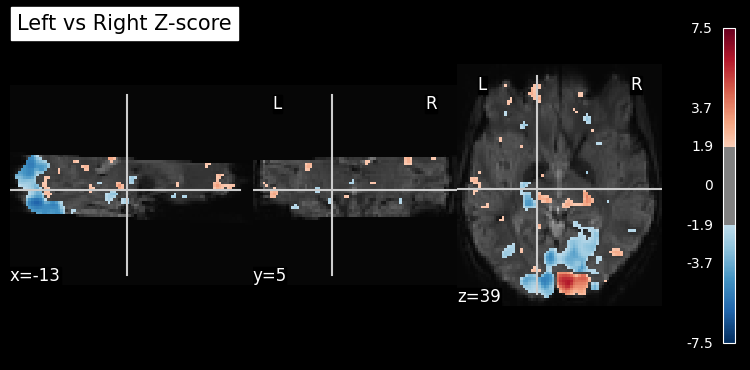

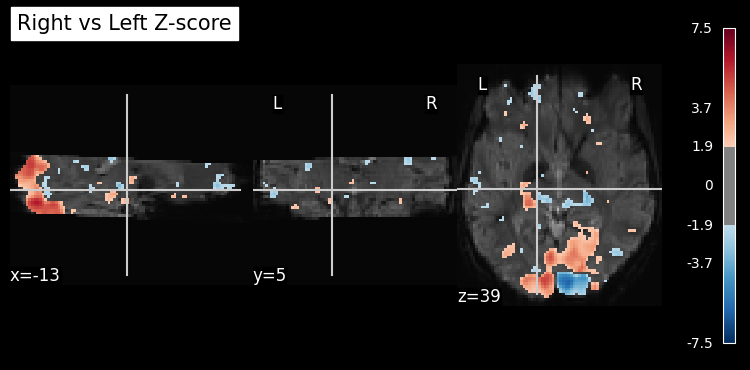

In [ ]:
from nilearn import plotting

# Calculate the mean fMRI image across the 4th dimension (time axis)
mean_img = ni.image.mean_img(fmri1_loc)

# Plot the statistical map
plotting.plot_stat_map(summary_statistics_left['z_score'], bg_img=mean_img, cut_coords=(-13.21, 5.51, 39.30), threshold=1.9, title='Left vs Right Z-score')
plotting.plot_stat_map(summary_statistics_right['z_score'], bg_img=mean_img, cut_coords=(-13.21, 5.51, 39.30), threshold=1.9, title='Right vs Left Z-score')

## Surface data visualization (using cifti data)

In [ ]:
# fmri1 = nib.load(f"sub-05_task-rest_space-fsLR_den-91k_bold.dtseries.nii").get_fdata()
# print(fmri1.shape)

# with fuckit:
#     ds = cx.Vertex(hcp.cortex_data(fmri1[0,:]),'hcp',cmap='jet')
#     cx.quickshow(ds)

## Data cleaning

In [ ]:
from scipy.ndimage import label,map_coordinates
from nilearn.image import resample_to_img  # For resampling

In [ ]:
threshold = 1.96  # Change this based on your needs

lr_path = f'{path}/sub-05/sub-05_lr_z_score_less_conf.nii.gz'
lr_data = nib.load(lr_path)
lr_z_scores = lr_data.get_fdata()

# Apply threshold
# lr_thresholded = np.where(np.abs(lr_z_scores) >= threshold, lr_z_scores, 0)
lr_thresholded = np.where(lr_z_scores >= threshold, lr_z_scores, 0)

# Save thresholded map
lr_output_path = f'{path}/sub-05/sub-05_lr_z_score_less_conf_thresholded.nii.gz'
nib.save(nib.Nifti1Image(lr_thresholded, lr_data.affine, lr_data.header), lr_output_path)

In [ ]:
print(nib.load('/home/mnili/sub-05/sub-05_lr_z_score_less_conf_thresholded.nii.gz').shape)
print(nib.load('/home/mnili/sub-05/lh_LGN.nii.gz').shape)

## Resample to target space

In [ ]:
def resample_to_target(source_nii, target_nii, order=1):
    """
    Resample a source NIfTI image to match the space (affine and shape) of a target image.
    Parameters:
        source_nii: nib.Nifti1Image
            The source image to be resampled.
        target_nii: nib.Nifti1Image
            The target image providing the reference space.
        order: int
            Interpolation order: 0 (nearest), 1 (linear), etc.
    Returns:
        numpy.ndarray
            The resampled source data in the target space.
    """
    source_data = source_nii.get_fdata()
    source_affine = source_nii.affine

    target_shape = target_nii.shape
    target_affine = target_nii.affine

    # Create a grid of voxel coordinates in the target space
    target_grid = np.meshgrid(
        np.arange(target_shape[0]),
        np.arange(target_shape[1]),
        np.arange(target_shape[2]),
        indexing='ij'
    )

    # Flatten the voxel grid to a 4xN matrix
    target_vox_coords = np.vstack([
        target_grid[0].ravel(),
        target_grid[1].ravel(),
        target_grid[2].ravel(),
        np.ones(np.prod(target_shape))
    ])

    # Convert voxel coordinates to world coordinates (RAS)
    target_world_coords = target_affine @ target_vox_coords

    # Convert world coordinates to source voxel coordinates
    inv_source_affine = np.linalg.inv(source_affine)
    source_vox_coords = inv_source_affine @ target_world_coords

    # Sample source data at target voxel coordinates
    resampled_flat = map_coordinates(
        source_data,
        source_vox_coords[:3],
        order=order,
        mode='constant',
        cval=0
    )

    # Reshape the flat result to the target shape
    resampled_data = resampled_flat.reshape(target_shape)

    return resampled_data

def apply_lgn_mask_on_zscore(zscore_path, lgn_path, output_path):
    """
    Resample a z-score image to match LGN mask space and apply the LGN mask.
    Saves the masked output to the given path.

    Parameters:
        zscore_path (str): Path to the input z-score NIfTI file.
        lgn_path (str): Path to the LGN mask NIfTI file.
        output_path (str): Path to save the masked z-score NIfTI output.
    """
    # Load z-score and LGN images
    zscore_nii = nib.load(zscore_path)
    lgn_nii = nib.load(lgn_path)

    # Clean z-score data (remove NaNs and negative values)
    zscore = zscore_nii.get_fdata()
    zscore[np.isnan(zscore)] = 0
    zscore[zscore < 0] = 0

    # Resample the z-score image to match the LGN mask space
    zscore_resampled = resample_to_target(zscore_nii, lgn_nii, order=1)

    # Generate binary LGN mask
    lgn = lgn_nii.get_fdata()
    lgn_mask = (lgn > 0.5).astype(np.float32)

    # Apply the LGN mask on the resampled z-score data
    masked_data = zscore_resampled * lgn_mask
    print(masked_data.sum())

    # Save the result to the specified output path
    masked_nii = nib.Nifti1Image(masked_data, lgn_nii.affine, lgn_nii.header)
    nib.save(masked_nii, output_path)

    # print(f"Done. Masked z-score image saved to:\n{output_path}")

In [ ]:
apply_lgn_mask_on_zscore(
    zscore_path='/home/mnili/sub-05/sub-05_lr_z_score_less_conf_thresholded.nii.gz',
    lgn_path='/home/mnili/sub-05/lh_LGN.nii.gz',
    output_path='/home/mnili/sub-05/sub-05_lgn_masked_zscore_resampled.nii.gz'
)

## Overlap functional patch with anatomical ROI

In [ ]:
# Paths to the files
z_stat_path = "/home/mnili/results/zscores_loc/sub-05/sub-05_rl_z_score_thresholded.nii.gz"
lgn_mask_path = "/home/mnili/results/ROIs_anat/sub-05/lh_LGN.nii.gz"
output_dir = "/home/mnili/results"

#  Load the z-stat image
z_stat_img = nib.load(z_stat_path)
z_stat_data = z_stat_img.get_fdata()

# Load the LGN mask and resample it to match the z-stat image
lgn_mask_img = nib.load(lgn_mask_path)
resampled_lgn_mask_img = resample_to_img(lgn_mask_img, z_stat_img, interpolation="nearest")
resampled_lgn_mask_data = resampled_lgn_mask_img.get_fdata()

# Ensure binary mask for LGN
lgn_binary_mask = (resampled_lgn_mask_data > 0).astype(int)

# Find blobs in z_stat file
z_stat_binary = (z_stat_data != 0).astype(int)
labeled_blobs, num_blobs = label(z_stat_binary)

# Identify the label of the blob overlapping with LGN
overlap_labels = np.unique(labeled_blobs[lgn_binary_mask > 0])
overlap_labels = overlap_labels[overlap_labels > 0]  # Exclude background

if len(overlap_labels) > 0:
    for label_id in overlap_labels:
        # Extract the entire blob
        blob_mask = (labeled_blobs == label_id)

        # Extract overlapping region
        overlap_region = blob_mask & (lgn_binary_mask > 0)

        # Extract non-overlapping region of the same blob
        non_overlap_region = blob_mask & ~(lgn_binary_mask > 0)

        # Save the results
        overlap_img = nib.Nifti1Image(overlap_region.astype(int), z_stat_img.affine, z_stat_img.header)
        nib.save(overlap_img, f"{output_dir}/overlap_blob_{label_id}.nii.gz")

        non_overlap_img = nib.Nifti1Image(non_overlap_region.astype(int), z_stat_img.affine, z_stat_img.header)
        nib.save(non_overlap_img, f"{output_dir}/non_overlap_blob_{label_id}.nii.gz")

else:
    pass

![5.png](attachment:5.png)

![6.png](attachment:6.png)